<a href="https://colab.research.google.com/github/Ashishpathak78/DL_practice/blob/main/DLWeek8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2569 - val_loss: 0.1719
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1587 - val_loss: 0.1448
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1392 - val_loss: 0.1318
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1294 - val_loss: 0.1243
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1236 - val_loss: 0.1203
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1205 - val_loss: 0.1179
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1184 - val_loss: 0.1162
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1167 - val_loss: 0.1147
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1152 - val_loss: 0.1136
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1139 - val_loss: 0.1122
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2391 - val_loss: 0.1656
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

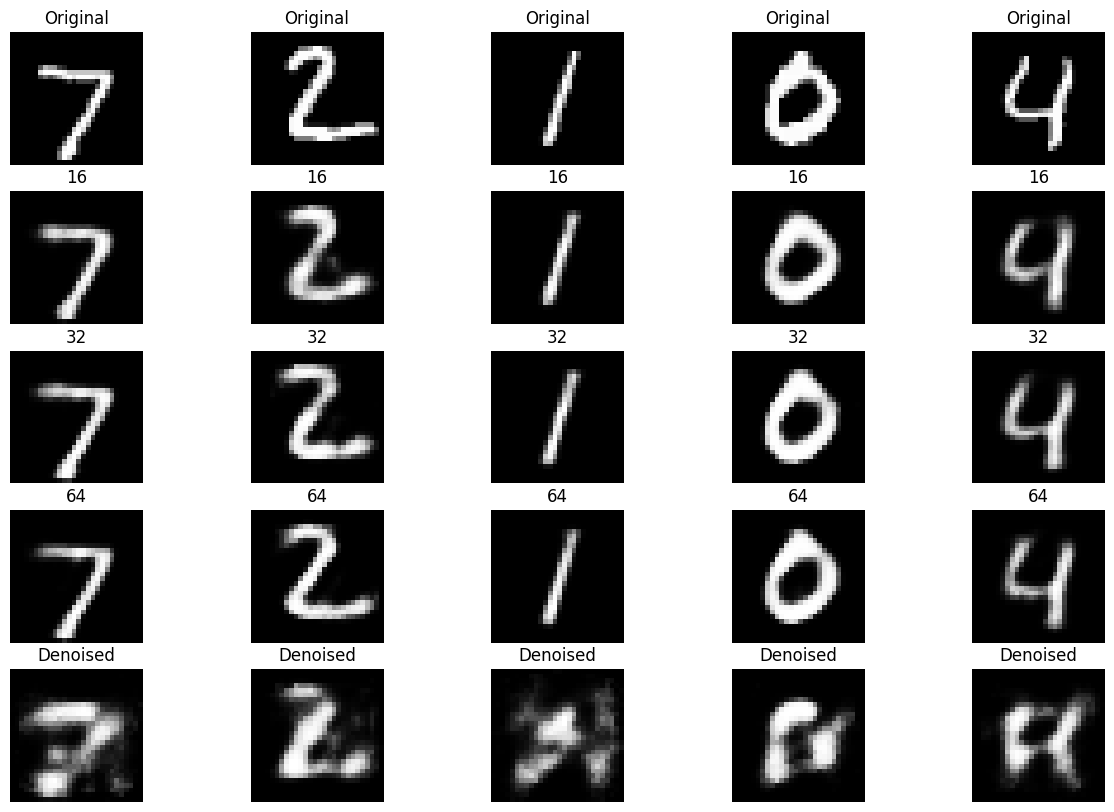

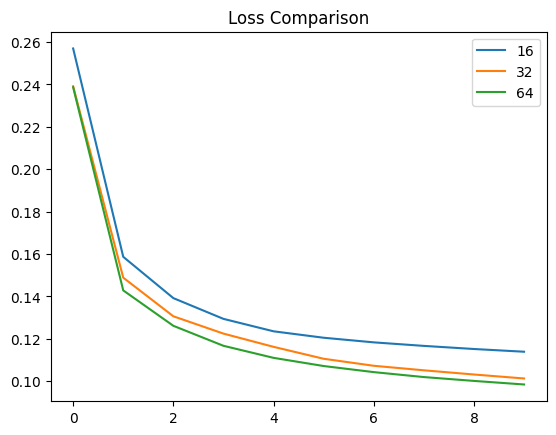

In [2]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras import regularizers

# ===============================
# 2. LOAD + PREPROCESS DATA
# ===============================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# ===============================
# 3. MODEL BUILDER FUNCTION
# ===============================
def build_autoencoder(bottleneck=32, activation='relu', dropout=False, sparse=False):

    input_layer = Input(shape=(784,))

    x = Dense(128, activation=activation)(input_layer)

    if dropout:
        x = Dropout(0.2)(x)

    x = Dense(64, activation=activation)(x)

    if sparse:
        encoded = Dense(bottleneck, activation=activation,
                        activity_regularizer=regularizers.l1(1e-5))(x)
    else:
        encoded = Dense(bottleneck, activation=activation)(x)

    x = Dense(64, activation=activation)(encoded)
    x = Dense(128, activation=activation)(x)
    decoded = Dense(784, activation='sigmoid')(x)

    model = Model(input_layer, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# ===============================
# 4. CREATE DIFFERENT MODELS
# ===============================
model_small = build_autoencoder(16)
model_medium = build_autoencoder(32)
model_large = build_autoencoder(64)

model_dropout = build_autoencoder(32, dropout=True)
model_sparse = build_autoencoder(32, sparse=True)

# ===============================
# 5. TRAIN MODELS
# ===============================
history_small = model_small.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
history_medium = model_medium.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
history_large = model_large.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

# ===============================
# 6. ADD NOISE (DENOISING TEST)
# ===============================
noise_factor = 0.4
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

decoded_small = model_small.predict(x_test)
decoded_medium = model_medium.predict(x_test)
decoded_large = model_large.predict(x_test)

decoded_noisy = model_medium.predict(x_test_noisy)

# ===============================
# 7. VISUALIZATION
# ===============================
n = 5
plt.figure(figsize=(15,10))

for i in range(n):
    # Original
    plt.subplot(5, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Small bottleneck
    plt.subplot(5, n, i+1+n)
    plt.imshow(decoded_small[i].reshape(28,28), cmap='gray')
    plt.title("16")
    plt.axis('off')

    # Medium
    plt.subplot(5, n, i+1+2*n)
    plt.imshow(decoded_medium[i].reshape(28,28), cmap='gray')
    plt.title("32")
    plt.axis('off')

    # Large
    plt.subplot(5, n, i+1+3*n)
    plt.imshow(decoded_large[i].reshape(28,28), cmap='gray')
    plt.title("64")
    plt.axis('off')

    # Noisy → Reconstructed
    plt.subplot(5, n, i+1+4*n)
    plt.imshow(decoded_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

# ===============================
# 8. LOSS GRAPH
# ===============================
plt.plot(history_small.history['loss'], label="16")
plt.plot(history_medium.history['loss'], label="32")
plt.plot(history_large.history['loss'], label="64")
plt.legend()
plt.title("Loss Comparison")
plt.show()

In [3]:
from sklearn.metrics import mean_squared_error

def calculate_mse(model, x_test):
    decoded = model.predict(x_test)
    mse = np.mean(np.square(x_test - decoded))
    return mse

mse_16 = calculate_mse(model_small, x_test)
mse_32 = calculate_mse(model_medium, x_test)
mse_64 = calculate_mse(model_large, x_test)

print("MSE (16):", mse_16)
print("MSE (32):", mse_32)
print("MSE (64):", mse_64)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MSE (16): 0.016635635576226646
MSE (32): 0.012410902524658882
MSE (64): 0.011389115232527804


In [5]:
acc_16 = 1 - mse_16
acc_32 = 1 - mse_32
acc_64 = 1 - mse_64

print("Accuracy-like (16):", acc_16)
print("Accuracy-like (32):", acc_32)
print("Accuracy-like (64):", acc_64)

Accuracy-like (16): 0.9833643644237734
Accuracy-like (32): 0.9875890974753411
Accuracy-like (64): 0.9886108847674722


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3101 - val_loss: 0.2207
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1992 - val_loss: 0.1815
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1727 - val_loss: 0.1627
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1578 - val_loss: 0.1514
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1491 - val_loss: 0.1450
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1444 - val_loss: 0.1414
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1414 - val_loss: 0.1389
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1391 - val_loss: 0.1371
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1373 - val_loss: 0.1351
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1357 - val_loss: 0.1336
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2775 - val_loss: 0.1940
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

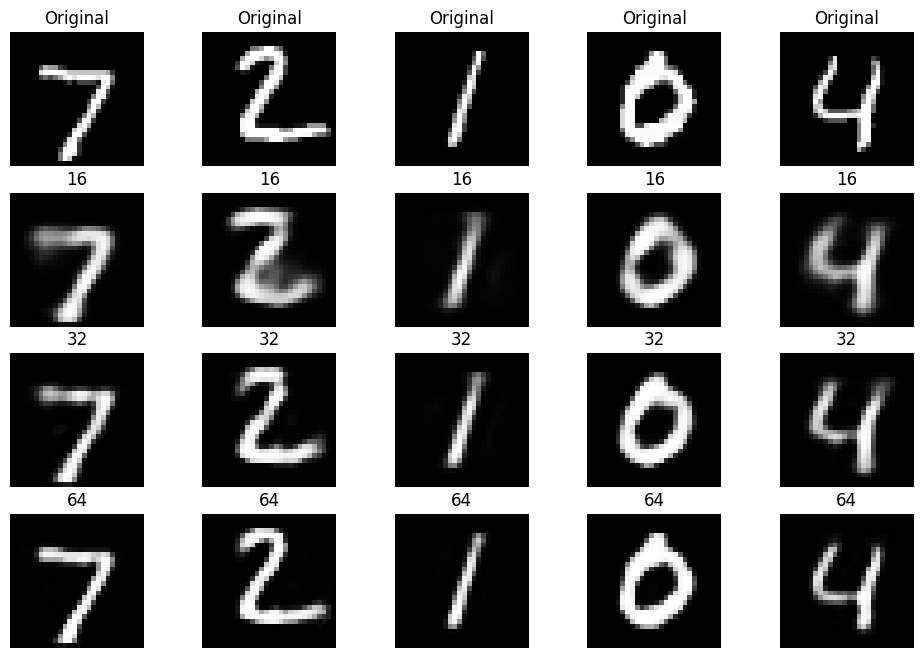

MSE 16: 0.023027445260486026
MSE 32: 0.010681741095487913
MSE 64: 0.0048246307774999185


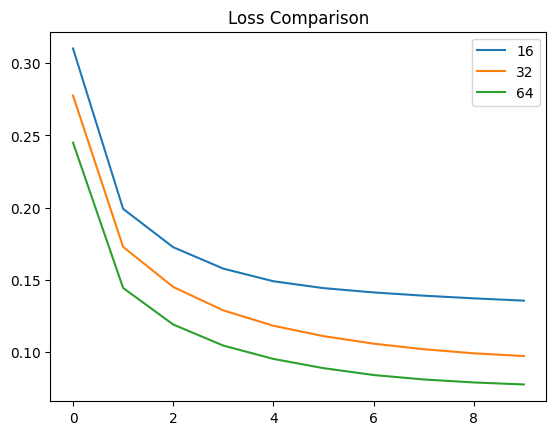

In [7]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# ===============================
# 2. LOAD DATA
# ===============================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

# ===============================
# 3. MODEL BUILDER (DIRECT)
# ===============================
def build_direct_autoencoder(latent_dim):

    input_layer = Input(shape=(784,))

    # Direct compression
    encoded = Dense(latent_dim, activation='relu')(input_layer)

    # Direct reconstruction
    decoded = Dense(784, activation='sigmoid')(encoded)

    model = Model(input_layer, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# ===============================
# 4. CREATE MODELS
# ===============================
model_16 = build_direct_autoencoder(16)
model_32 = build_direct_autoencoder(32)
model_64 = build_direct_autoencoder(64)

# ===============================
# 5. TRAIN
# ===============================
h16 = model_16.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
h32 = model_32.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
h64 = model_64.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

# ===============================
# 6. RECONSTRUCTION
# ===============================
d16 = model_16.predict(x_test)
d32 = model_32.predict(x_test)
d64 = model_64.predict(x_test)

# ===============================
# 7. VISUAL COMPARISON
# ===============================
n = 5
plt.figure(figsize=(12,8))

for i in range(n):
    # Original
    plt.subplot(4, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # 16
    plt.subplot(4, n, i+1+n)
    plt.imshow(d16[i].reshape(28,28), cmap='gray')
    plt.title("16")
    plt.axis('off')

    # 32
    plt.subplot(4, n, i+1+2*n)
    plt.imshow(d32[i].reshape(28,28), cmap='gray')
    plt.title("32")
    plt.axis('off')

    # 64
    plt.subplot(4, n, i+1+3*n)
    plt.imshow(d64[i].reshape(28,28), cmap='gray')
    plt.title("64")
    plt.axis('off')

plt.show()

# ===============================
# 8. MSE COMPARISON
# ===============================
def mse(x, y):
    return np.mean((x - y) ** 2)

print("MSE 16:", mse(x_test, d16))
print("MSE 32:", mse(x_test, d32))
print("MSE 64:", mse(x_test, d64))

# ===============================
# 9. LOSS GRAPH
# ===============================
plt.plot(h16.history['loss'], label='16')
plt.plot(h32.history['loss'], label='32')
plt.plot(h64.history['loss'], label='64')
plt.legend()
plt.title("Loss Comparison")
plt.show()

PCA vs AE

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0440
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0215
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0184
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0176
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0175
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0174
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0174
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0174
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0173
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
PCA MSE: 0.016828234980431678
Autoencoder MSE: 0.016904295573949926


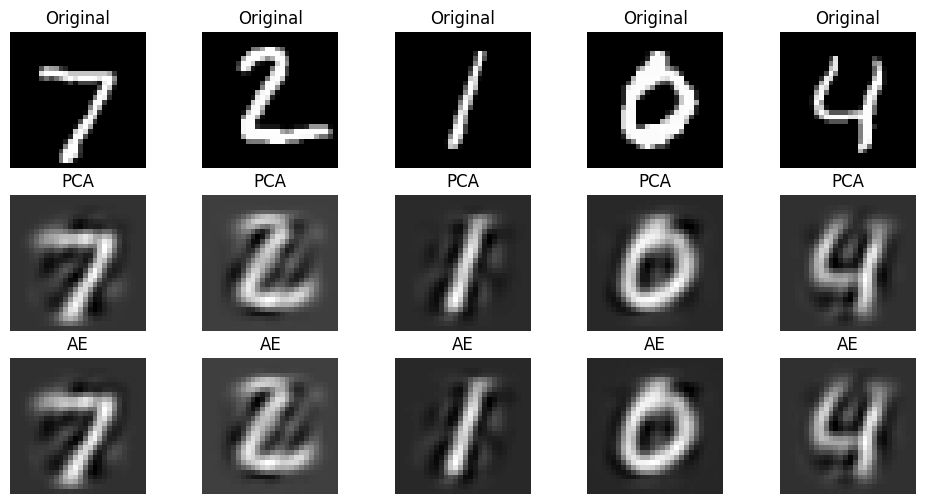

In [8]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# ===============================
# 2. LOAD DATA
# ===============================
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

# ===============================
# 3. PCA MODEL
# ===============================
pca = PCA(n_components=32)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

x_test_pca_recon = pca.inverse_transform(x_test_pca)

# ===============================
# 4. LINEAR AUTOENCODER
# ===============================
input_layer = Input(shape=(784,))

# IMPORTANT: linear activation
encoded = Dense(32, activation='linear')(input_layer)
decoded = Dense(784, activation='linear')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(x_train, x_train, epochs=10, batch_size=256)

x_test_ae = autoencoder.predict(x_test)

# ===============================
# 5. COMPARE MSE
# ===============================
mse_pca = mean_squared_error(x_test, x_test_pca_recon)
mse_ae = mean_squared_error(x_test, x_test_ae)

print("PCA MSE:", mse_pca)
print("Autoencoder MSE:", mse_ae)

# ===============================
# 6. VISUAL COMPARISON
# ===============================
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Original
    plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # PCA
    plt.subplot(3, n, i+1+n)
    plt.imshow(x_test_pca_recon[i].reshape(28,28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')

    # Autoencoder
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test_ae[i].reshape(28,28), cmap='gray')
    plt.title("AE")
    plt.axis('off')

plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Load data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

Undercomplete

In [10]:
def build_undercomplete(latent_dim):

    input_layer = Input(shape=(784,))

    # Compression
    encoded = Dense(latent_dim, activation='relu')(input_layer)

    # Reconstruction
    decoded = Dense(784, activation='sigmoid')(encoded)

    model = Model(input_layer, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# Different compression levels
under_16 = build_undercomplete(16)
under_32 = build_undercomplete(32)
under_64 = build_undercomplete(64)

Overcomplete

In [11]:
def build_overcomplete(latent_dim):

    input_layer = Input(shape=(784,))

    # Expansion
    encoded = Dense(latent_dim, activation='relu')(input_layer)

    # Reconstruction
    decoded = Dense(784, activation='sigmoid')(encoded)

    model = Model(input_layer, decoded)
    model.compile(optimizer='adam', loss='binary_crossentropy')

    return model

# Larger than input
over_1024 = build_overcomplete(1024)
over_2048 = build_overcomplete(2048)

In [12]:
under_16.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
under_32.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
under_64.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

over_1024.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))
over_2048.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3065 - val_loss: 0.2215
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1983 - val_loss: 0.1805
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1722 - val_loss: 0.1616
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1573 - val_loss: 0.1504
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1488 - val_loss: 0.1446
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1443 - val_loss: 0.1412
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1415 - val_loss: 0.1389
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1394 - val_loss: 0.1371
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1377 - val_loss: 0.1355
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1362 - val_loss: 0.1341
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2776 - val_loss: 0.1893
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step -

In [13]:
d16 = under_16.predict(x_test)
d32 = under_32.predict(x_test)
d64 = under_64.predict(x_test)

d1024 = over_1024.predict(x_test)
d2048 = over_2048.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Plot

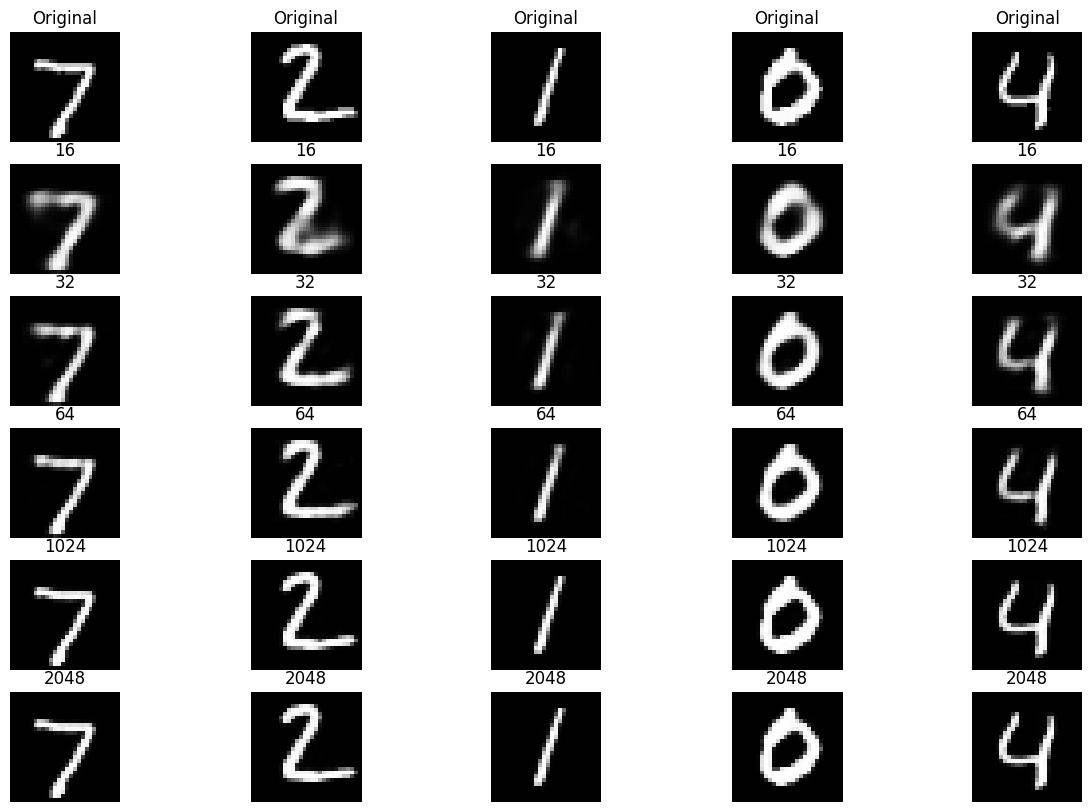

In [14]:
n = 5
plt.figure(figsize=(15,10))

for i in range(n):
    # Original
    plt.subplot(6, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Undercomplete
    plt.subplot(6, n, i+1+n)
    plt.imshow(d16[i].reshape(28,28), cmap='gray')
    plt.title("16")
    plt.axis('off')

    plt.subplot(6, n, i+1+2*n)
    plt.imshow(d32[i].reshape(28,28), cmap='gray')
    plt.title("32")
    plt.axis('off')

    plt.subplot(6, n, i+1+3*n)
    plt.imshow(d64[i].reshape(28,28), cmap='gray')
    plt.title("64")
    plt.axis('off')

    # Overcomplete
    plt.subplot(6, n, i+1+4*n)
    plt.imshow(d1024[i].reshape(28,28), cmap='gray')
    plt.title("1024")
    plt.axis('off')

    plt.subplot(6, n, i+1+5*n)
    plt.imshow(d2048[i].reshape(28,28), cmap='gray')
    plt.title("2048")
    plt.axis('off')

plt.show()

What extra neurons store:
      Redundant representations of input
      Combinations of pixel features
      Edge and stroke patterns
      Noise variations
      Alternative encodings of same digit

Observations on Undercomplete and Overcomplete Autoencoders
1. Compression Limits

          For different latent dimensions:

          16 dimensions provide very high compression (approximately 49 times reduction), yet the reconstructed digits are still recognizable.
          32 dimensions provide a good balance between compression and reconstruction quality.
          64 dimensions produce very clear reconstructions with minimal loss.
          1024 and 2048 dimensions do not perform compression and instead expand the representation.

          Conclusion: MNIST images can be effectively compressed to around 16–32 dimensions while preserving their essential structure.

2. Undercomplete Autoencoder Learns Essential Features

        In the case of smaller latent dimensions such as 16:

        The model retains the general shape of the digit.
        Fine details are lost.

        Conclusion: The model captures the essential structure of the image rather than exact pixel-level information.

3. Overcomplete Autoencoder Tends to Memorize

          For larger latent dimensions such as 1024 and 2048:

          The reconstructed output is almost identical to the input.
          The model does not perform meaningful compression.

          Conclusion: The model memorizes the input data instead of learning a compact representation.

4. Lack of Compression Does Not Imply Learning

          Overcomplete autoencoders do not enforce feature extraction.
          They can simply learn an identity mapping.

          Conclusion: Without constraints, overcomplete autoencoders fail to learn useful representations.

5. Extreme Compression Leads to Abstraction

          At very low dimensions such as 16:

          The reconstructed images appear simplified and slightly blurred.
          The basic structure of digits is still maintained.

          Conclusion: The model preserves high-level structural features while discarding fine details.

6. Redundancy in Image Data

              MNIST images contain many background pixels that do not contribute significantly to digit recognition.
              The autoencoder learns to ignore these redundant pixels.

              Conclusion: A large portion of image data is redundant, allowing significant compression without major information loss.

7. Existence of an Optimal Latent Dimension

        Very small dimensions lead to loss of detail.
        Very large dimensions lead to memorization.

        Conclusion: There exists an optimal latent size (around 32) that balances compression and reconstruction quality.

8. Overcomplete Autoencoders Require Regularization

        Without techniques such as sparsity or dropout, overcomplete models learn trivial identity mappings.

        Conclusion: Regularization is necessary to force meaningful feature learning in overcomplete autoencoders.

9. Human Perception vs Model Output

        Even when images are blurred (for example, with 16 dimensions), humans can still easily recognize the digits.

        Conclusion: Human perception is robust to loss of detail, and the model successfully preserves the most important visual features.